In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session


Plotting MC Policy with Exploring Starts


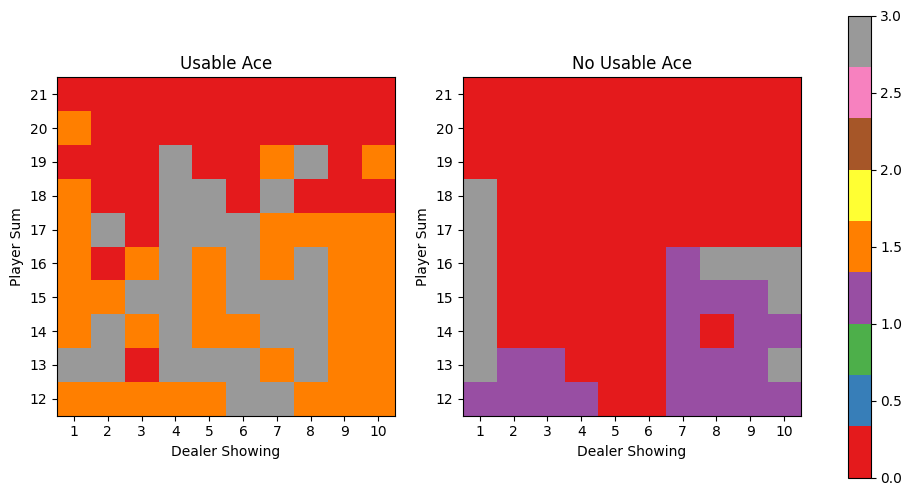


Plotting SARSA Policy


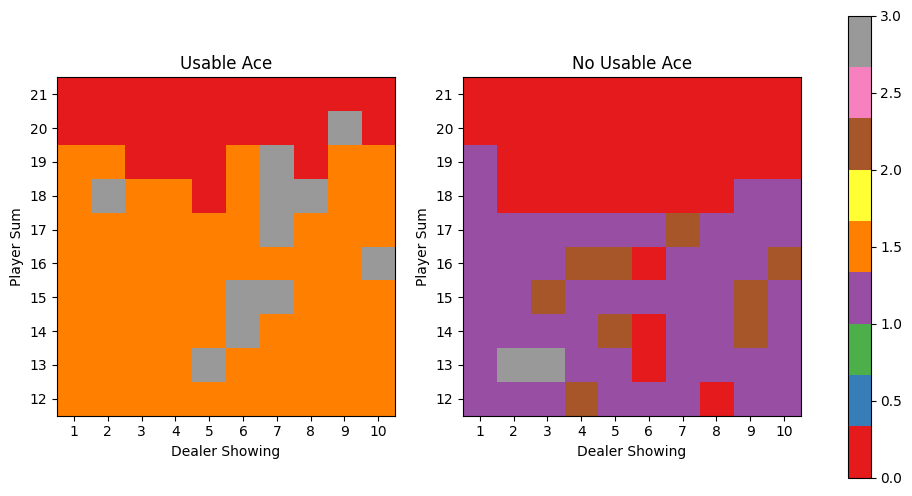


Plotting Q-Learning Policy


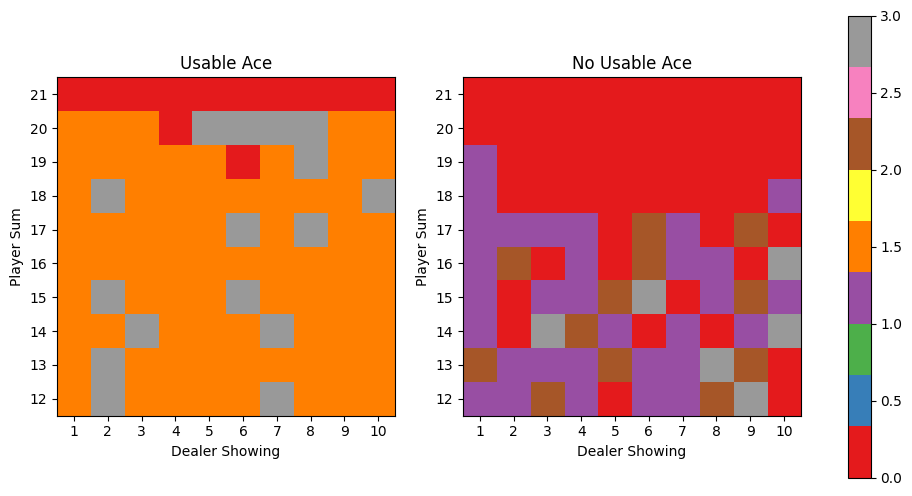



 Q-Value Comparisons for Key States 

State (20, 3, False):
  MC ES      : [ 0.639 -0.922 -1.815 -0.5  ]
  SARSA      : [ 8.412 -0.923  0.362  5.338]
  Q-Learning : [64.2    2.001 -1.915 44.991]

State (13, 10, False):
  MC ES      : [-0.55  -0.515 -0.933 -0.5  ]
  SARSA      : [ 0.219  1.563 -1.32   0.32 ]
  Q-Learning : [14.371 13.976  5.597 14.126]

State (14, 10, False):
  MC ES      : [-0.553 -0.462 -1.041 -0.5  ]
  SARSA      : [ 0.056  0.061 -0.688  0.046]
  Q-Learning : [19.494 17.471 16.347 19.571]

State (21, 2, True):
  MC ES      : [ 0.835  0.348  0.286 -0.5  ]
  SARSA      : [13.79   3.046  5.542  8.838]
  Q-Learning : [31.5    7.292 10.6   14.82 ]


 Overall Learned Action Preferences

MC Action Distribution:
  Action 0: 107 times
  Action 1: 104 times
  Action 2: 56 times
  Action 3: 13 times

SARSA Action Distribution:
  Action 0: 163 times
  Action 1: 188 times
  Action 2: 26 times
  Action 3: 2 times

Q-Learning Action Distribution:
  Action 0: 163 times
  Action 1:

In [4]:
# Blackjack RL with Splitting + All Major Algorithms 

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random

# Custom Blackjack Environment with Split Action
class BlackjackEnvSplit:
    def __init__(self, natural=False):
        self.action_space = [0, 1, 2, 3]  # stick=0, hit=1, double=2, surrender=3
        self.deck = [1,2,3,4,5,6,7,8,9,10,10,10,10]*4
        self.natural = natural
        self.reset()

    def draw_card(self):
        return random.choice(self.deck)

    def draw_hand(self):
        return [self.draw_card(), self.draw_card()]

    def sum_hand(self, hand):
        if self.usable_ace(hand):
            return sum(hand) + 10
        return sum(hand)

    def usable_ace(self, hand):
        return 1 in hand and sum(hand) + 10 <= 21

    def is_bust(self, hand):
        return self.sum_hand(hand) > 21

    def score(self, hand):
        return 0 if self.is_bust(hand) else self.sum_hand(hand)

    def is_natural(self, hand):
        return sorted(hand) == [1, 10]

    def reset(self):
        self.dealer = self.draw_hand()
        self.player = self.draw_hand()
        return self._get_obs()

    def _get_obs(self):
        return (self.sum_hand(self.player), self.dealer[0], self.usable_ace(self.player))

    def step(self, action):
        if action == 0:  # stick
            while self.sum_hand(self.dealer) < 17:
                self.dealer.append(self.draw_card())
            reward = cmp(self.score(self.player), self.score(self.dealer))
            return self._get_obs(), reward, True, {}

        elif action == 1:  # hit
            self.player.append(self.draw_card())
            if self.is_bust(self.player):
                return self._get_obs(), -1, True, {}
            return self._get_obs(), 0, False, {}

        elif action == 2:  # double
            self.player.append(self.draw_card())
            if self.is_bust(self.player):
                return self._get_obs(), -2, True, {}
            while self.sum_hand(self.dealer) < 17:
                self.dealer.append(self.draw_card())
            reward = 2 * cmp(self.score(self.player), self.score(self.dealer))
            return self._get_obs(), reward, True, {}

        elif action == 3:  # surrender
            return self._get_obs(), -0.5, True, {}

def cmp(a, b):
    return int(a > b) - int(a < b)

# Monte Carlo Control with Exploring Starts

def mc_es(env, episodes=100000):
    Q = defaultdict(lambda: np.zeros(len(env.action_space)))
    returns = defaultdict(list)

    for _ in range(episodes):
        episode = []
        state = env.reset()
        action = random.choice(env.action_space)

        while True:
            next_state, reward, done, _ = env.step(action)
            episode.append((state, action, reward))
            if done:
                break
            state = next_state
            action = np.argmax(Q[state]) if state in Q else random.choice(env.action_space)

        G = 0
        for t in reversed(range(len(episode))):
            s, a, r = episode[t]
            G = G + r
            if not any((x[0] == s and x[1] == a) for x in episode[:t]):
                returns[(s, a)].append(G)
                Q[s][a] = np.mean(returns[(s, a)])

    policy = {s: np.argmax(a) for s, a in Q.items()}
    return Q, policy

# SARSA Algorithm

def sarsa(env, episodes=100000, alpha=0.1, gamma=1.0, epsilon=0.1):
    Q = defaultdict(lambda: np.zeros(len(env.action_space)))

    for _ in range(episodes):
        state = env.reset()
        action = epsilon_greedy(Q, state, epsilon, env)

        while True:
            next_state, reward, done, _ = env.step(action)
            next_action = epsilon_greedy(Q, next_state, epsilon, env)

            Q[state][action] += alpha * (reward + gamma * Q[next_state][next_action] - Q[state][action])

            if done:
                break
            state, action = next_state, next_action

    policy = {s: np.argmax(a) for s, a in Q.items()}
    return Q, policy

# Q-Learning Algorithm

def q_learning(env, episodes=100000, alpha=0.1, gamma=1.0, epsilon=0.1):
    Q = defaultdict(lambda: np.zeros(len(env.action_space)))

    for _ in range(episodes):
        state = env.reset()

        while True:
            action = epsilon_greedy(Q, state, epsilon, env)
            next_state, reward, done, _ = env.step(action)
            Q[state][action] += alpha * (reward + gamma * np.max(Q[next_state]) - Q[state][action])

            if done:
                break
            state = next_state

    policy = {s: np.argmax(a) for s, a in Q.items()}
    return Q, policy

# Epsilon-Greedy Action Selection

def epsilon_greedy(Q, state, epsilon, env):
    if random.random() < epsilon:
        return random.choice(env.action_space)
    return np.argmax(Q[state])

# Policy Plotting

def plot_policy(policy):
    usable = np.zeros((10, 10))
    no_usable = np.zeros((10, 10))

    for ((player, dealer, ace), action) in policy.items():
        if 12 <= player <= 21 and 1 <= dealer <= 10:
            i, j = player - 12, dealer - 1
            if ace:
                usable[i, j] = action
            else:
                no_usable[i, j] = action

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    for ax, data, title in zip([ax1, ax2], [usable, no_usable], ['Usable Ace', 'No Usable Ace']):
        c = ax.imshow(data, cmap='Set1', origin='lower')
        ax.set_title(title)
        ax.set_xlabel('Dealer Showing')
        ax.set_ylabel('Player Sum')
        ax.set_xticks(np.arange(10))
        ax.set_xticklabels(np.arange(1, 11))
        ax.set_yticks(np.arange(10))
        ax.set_yticklabels(np.arange(12, 22))
    plt.colorbar(c, ax=[ax1, ax2])
    plt.show()

# Run the algorithms

env = BlackjackEnvSplit()
Q_mc, policy_mc = mc_es(env)
Q_sarsa, policy_sarsa = sarsa(env)
Q_ql, policy_ql = q_learning(env)

print("\nPlotting MC Policy with Exploring Starts")
plot_policy(policy_mc)
print("\nPlotting SARSA Policy")
plot_policy(policy_sarsa)
print("\nPlotting Q-Learning Policy")
plot_policy(policy_ql)

# Display sample Q-values for comparison
key_states = [
    (20, 3, False),
    (13, 10, False),
    (14, 10, False),
    (21, 2, True)
]

print("\n\n Q-Value Comparisons for Key States ")
for state in key_states:
    print(f"\nState {state}:")
    print(f"  MC ES      : {np.round(Q_mc.get(state, np.zeros(4)), 3)}")
    print(f"  SARSA      : {np.round(Q_sarsa.get(state, np.zeros(4)), 3)}")
    print(f"  Q-Learning : {np.round(Q_ql.get(state, np.zeros(4)), 3)}")

#  summary statistics
print("\n\n Overall Learned Action Preferences")
def summarize_policy(policy, name):
    action_counts = np.zeros(4)
    for action in policy.values():
        action_counts[action] += 1
    print(f"\n{name} Action Distribution:")
    for i, count in enumerate(action_counts):
        print(f"  Action {i}: {int(count)} times")

summarize_policy(policy_mc, "MC")
summarize_policy(policy_sarsa, "SARSA")
summarize_policy(policy_ql, "Q-Learning")